# IELTS Model Performance & Augmentation Analysis

This notebook evaluates the **pre-trained** IELTS scoring models and analyses data augmentation strategies.

1. **Training Curves** — Visualise loss & LR schedule from `training_history.json`
2. **Model Evaluation** — Load `sayardesk_model.pth` and compute per-criterion metrics on a held-out test set
3. **Weights & Biases** — Inspect learned parameters of the 4 task heads
4. **Data Augmentation** — Analyse score distributions and augment truly underrepresented (low-band) essays

---
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer
from sentence_transformers import SentenceTransformer, util
import spacy
from spellchecker import SpellChecker
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import textstat
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
import matplotlib.pyplot as plt
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

CRITERIA = ['Task_Achievement', 'Coherence_Cohesion', 'Lexical_Resource', 'Grammar_Range']
CRITERIA_SHORT = ['TA', 'CC', 'LR', 'GRA']
BASE_DIR = r'D:\Projects\Senior-Capstone-Project'
ANALYTICS_DIR = os.path.join(BASE_DIR, 'ielts_engine', 'analytics')

d:\Projects\Senior-Capstone-Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [2]:
# Load NLP tools
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    os.system('python -m spacy download en_core_web_sm')
    nlp = spacy.load('en_core_web_sm')

spell = SpellChecker()
sim_model = SentenceTransformer('all-mpnet-base-v2')
print('NLP tools loaded.')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 791.64it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NLP tools loaded.


In [3]:
# Model Architecture (must match advanced_model.py exactly)

def extract_advanced_features(row):
    essay = str(row.get('Essay_Text', ''))
    prompt = str(row.get('Question', ''))
    doc = nlp(essay)

    # Grammar
    lengths = [len(s) for s in doc.sents]
    var = np.var(lengths) if lengths else 0
    dep_clauses = sum(1 for t in doc if t.dep_ in ['advcl', 'relcl', 'ccomp'])

    # Lexical
    tokens = [t.text.lower() for t in doc if t.is_alpha]
    unique = set(tokens)
    ttr = len(unique) / len(tokens) if tokens else 0
    misspelled_count = len(spell.unknown(tokens)) if tokens else 0
    error_density = (misspelled_count / len(tokens)) * 100 if tokens else 0

    # Task Achievement
    sim = 0.0
    if essay and prompt:
        e_emb = sim_model.encode(essay, convert_to_numpy=True)
        p_emb = sim_model.encode(prompt, convert_to_numpy=True)
        sim = util.cos_sim(e_emb, p_emb).item()

    # Readability
    flesch = textstat.flesch_reading_ease(essay)

    # Cohesion Markers
    cohesion_words = {'however', 'furthermore', 'moreover', 'consequently', 'therefore', 'thus', 'hence', 'nevertheless', 'additionally', 'meanwhile'}
    cohesion = sum(1 for t in tokens if t in cohesion_words)

    return [float(var), float(dep_clauses), float(ttr), float(misspelled_count), float(sim), float(flesch), float(cohesion), float(error_density)]

class EssayDataset(Dataset):
    def __init__(self, texts, feats, targets, tokenizer, max_len=512):
        self.texts = texts
        self.feats = torch.tensor(feats, dtype=torch.float)
        self.targets = torch.tensor(targets, dtype=torch.float)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        enc = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'ids': enc['input_ids'].flatten(),
            'mask': enc['attention_mask'].flatten(),
            'feats': self.feats[idx],
            'targets': self.targets[idx]
        }

class IELTSMultiTaskModel(nn.Module):
    def __init__(self, n_extra_features=8):
        super(IELTSMultiTaskModel, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.drop = nn.Dropout(0.3)
        input_size = self.bert.config.hidden_size + n_extra_features
        
        # Shared base with 4 task-specific heads
        self.ta_head = nn.Linear(input_size, 1)
        self.cc_head = nn.Linear(input_size, 1)
        self.lr_head = nn.Linear(input_size, 1)
        self.gra_head = nn.Linear(input_size, 1)

    def forward(self, ids, mask, feats):
        out = self.bert(ids, attention_mask=mask)
        pooled = self.drop(out.pooler_output)
        combined = torch.cat((pooled, feats), dim=1)
        return (self.ta_head(combined), self.cc_head(combined), \
               self.lr_head(combined), self.gra_head(combined)), combined

In [4]:
# Load & Prepare Data
df1 = pd.read_csv(os.path.join(BASE_DIR, 'Datasets', 'Scraping Data', 'combined_ielts_essays_fixed.csv'))
df2 = pd.read_csv(os.path.join(BASE_DIR, 'Datasets', 'AI Generated Dataset', 'ielts_gemini_fixed.csv'))
df = pd.concat([df1, df2]).dropna(subset=['Essay_Text', 'Question'] + CRITERIA)
print(f'Combined dataset: {len(df)} essays')

print('Extracting linguistic features (this may take a few minutes)...')
feature_list = df.apply(extract_advanced_features, axis=1).tolist()
feats = np.array(feature_list)

scaler = StandardScaler()
feats_scaled = scaler.fit_transform(feats)
targets = df[CRITERIA].values
print(f'Features shape: {feats_scaled.shape}')
print('Data ready.')

Combined dataset: 585 essays
Extracting linguistic features (this may take a few minutes)...
Features shape: (585, 8)
Data ready.


---
## 2. Training Curves (from `training_history.json`)

In [5]:
# Load training history saved by advanced_model.py
HISTORY_PATH = os.path.join(BASE_DIR, 'training_history.json')
HAS_HISTORY = False

if os.path.exists(HISTORY_PATH):
    with open(HISTORY_PATH) as f:
        history = json.load(f)
    HAS_HISTORY = True
    print(f'Loaded training history: {len(history.get("train_loss",[]))} epochs recorded.')
else:
    print('WARNING: training_history.json not found.')
    print('Run advanced_model.py first to generate training telemetry.')
    print('Skipping training curve plots.')

Loaded training history: 15 epochs recorded.


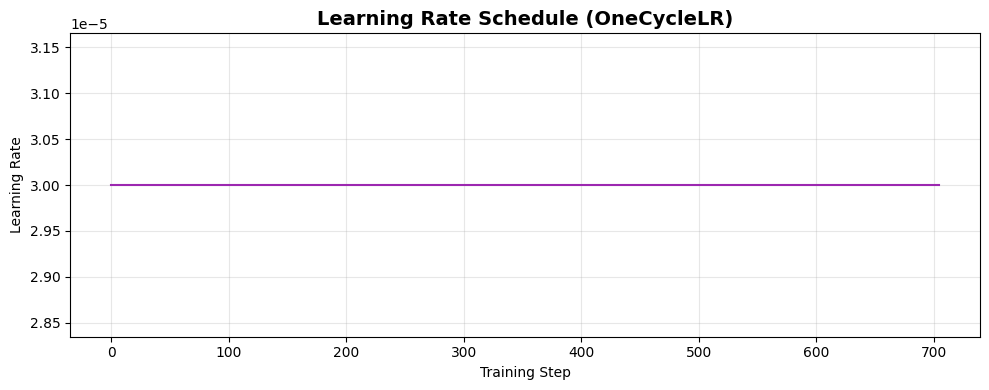

In [6]:
# Plot: Learning Rate Schedule over Training Steps
if HAS_HISTORY and 'lr_log' in history:
    fig, ax = plt.subplots(figsize=(10, 4))
    steps = list(range(len(history['lr_log'])))
    ax.plot(steps, history['lr_log'], color='#9C27B0', linewidth=1.5)
    ax.set_xlabel('Training Step')
    ax.set_ylabel('Learning Rate')
    ax.set_title('Learning Rate Schedule (OneCycleLR)', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('No LR log available.')

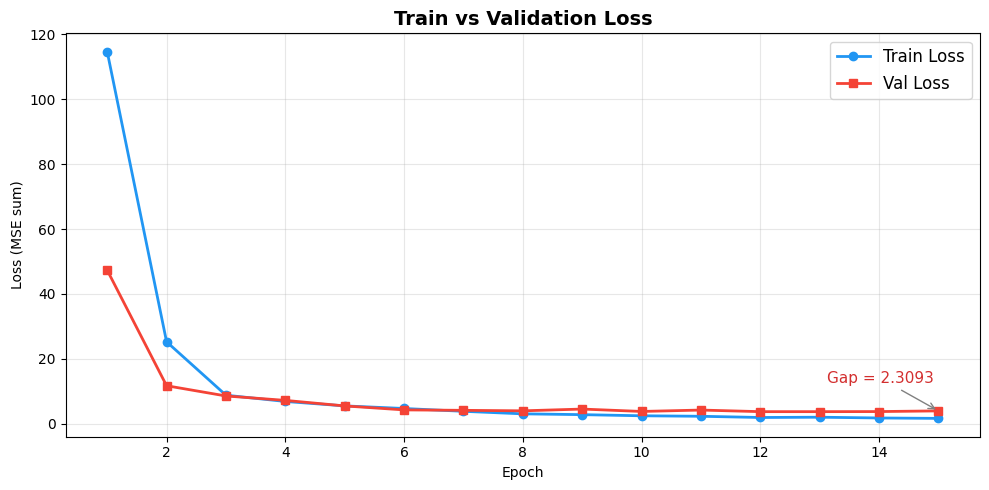

In [7]:
# Plot: Train vs Validation Loss per Epoch
if HAS_HISTORY:
    epochs_range = range(1, len(history['train_loss']) + 1)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(epochs_range, history['train_loss'], 'o-', color='#2196F3', linewidth=2, label='Train Loss')
    ax.plot(epochs_range, history['val_loss'], 's-', color='#F44336', linewidth=2, label='Val Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss (MSE sum)')
    ax.set_title('Train vs Validation Loss', fontsize=14, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)

    # Annotate gap
    final_gap = history['val_loss'][-1] - history['train_loss'][-1]
    ax.annotate(f'Gap = {final_gap:.4f}',
                xy=(len(history['train_loss']), history['val_loss'][-1]),
                xytext=(-80, 20), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='gray'),
                fontsize=11, color='#D32F2F')
    plt.tight_layout()
    plt.show()
else:
    print('No training history available.')

---
## 3. Model Evaluation (Pre-Trained)

In [8]:
# Load pre-trained BERT and XGBoost checkpoints
MODEL_PATH = os.path.join(BASE_DIR, 'sayardesk_model_best.pth')
XGB_PATH = os.path.join(BASE_DIR, 'hybrid_xgb_model.joblib')

N_FEATURES = feats_scaled.shape[1]
print(f"Detected {N_FEATURES} features.")

model = IELTSMultiTaskModel(n_extra_features=N_FEATURES).to(device)
try:
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    print(f'Loaded BERT checkpoint: {MODEL_PATH}')
except Exception as e:
    print(f"Error loading BERT model: {e}")

try:
    xgb_model = joblib.load(XGB_PATH)
    print(f'Loaded XGBoost checkpoint: {XGB_PATH}')
except Exception as e:
    print(f"Error loading XGBoost model: {e}")

# Reproduce the exact same 3-way split used during training (same random_state)
train_txt, test_txt, train_f, test_f, train_y, test_y = train_test_split(
    df['Essay_Text'].values, feats_scaled, targets, test_size=0.2, random_state=42
)
train_txt, val_txt, train_f, val_f, train_y, val_y = train_test_split(
    train_txt, train_f, train_y, test_size=0.2, random_state=42
)

tok = BertTokenizer.from_pretrained('bert-base-uncased')
BATCH_SIZE = 16

test_loader = DataLoader(EssayDataset(test_txt, test_f, test_y, tok), batch_size=BATCH_SIZE, shuffle=False)
val_loader  = DataLoader(EssayDataset(val_txt, val_f, val_y, tok), batch_size=BATCH_SIZE, shuffle=False)
print(f'Split sizes — Train: {len(train_txt)}, Val: {len(val_txt)}, Test: {len(test_txt)}')


Detected 8 features.


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 419.04it/s, Materializing param=pooler.dense.weight]                               
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded BERT checkpoint: D:\Projects\Senior-Capstone-Project\sayardesk_model_best.pth
Loaded XGBoost checkpoint: D:\Projects\Senior-Capstone-Project\hybrid_xgb_model.joblib
Split sizes — Train: 374, Val: 94, Test: 117


In [9]:
def evaluate_model(model, xgb_model, loader, device):
    """Run models on a DataLoader and return BERT and Hybrid (XGB) predictions."""
    model.eval()
    all_bert_preds = []
    all_hybrid_preds = []
    all_targets = []
    
    # We also need to extract hybrid features (BERT pooled + linguistic) for XGBoost
    hybrid_features_list = []

    with torch.no_grad():
        for batch in loader:
            ids  = batch['ids'].to(device)
            mask = batch['mask'].to(device)
            f    = batch['feats'].to(device)
            t    = batch['targets'].to(device)

            (ta, cc, lr_out, gra), hybrid_feats = model(ids, mask, f)
            
            # BERT Predictions
            preds = torch.stack([ta.squeeze(), cc.squeeze(),
                                 lr_out.squeeze(), gra.squeeze()], dim=1)
            all_bert_preds.append(preds.cpu().numpy())
            
            # Save hybrid features for XGBoost stage
            hybrid_features_list.append(hybrid_feats.cpu().numpy())
            all_targets.append(t.cpu().numpy())

    y_bert = np.vstack(all_bert_preds)
    y_true = np.vstack(all_targets)
    X_hybrid = np.vstack(hybrid_features_list)
    
    # XGBoost Predictions
    y_hybrid = xgb_model.predict(X_hybrid)

    return y_bert, y_hybrid, y_true

# Run Evaluation
y_bert, y_hybrid, y_true = evaluate_model(model, xgb_model, test_loader, device)

def print_metrics(y_true, y_pred, label):
    print(f"\n--- {label} Performance ---")
    for i, criterion in enumerate(CRITERIA):
        mse = mean_squared_error(y_true[:, i], y_pred[:, i])
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        print(f"{criterion:20} | MSE: {mse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")

print_metrics(y_true, y_bert, "BERT Multi-Task Only")
print_metrics(y_true, y_hybrid, "Hybrid BERT-XGBoost (Production)")


--- BERT Multi-Task Only Performance ---
Task_Achievement     | MSE: 0.5498 | MAE: 0.5277 | R2: 0.7370
Coherence_Cohesion   | MSE: 0.8825 | MAE: 0.7217 | R2: 0.6003
Lexical_Resource     | MSE: 1.0131 | MAE: 0.7596 | R2: 0.6398
Grammar_Range        | MSE: 1.2337 | MAE: 0.8644 | R2: 0.5174

--- Hybrid BERT-XGBoost (Production) Performance ---
Task_Achievement     | MSE: 0.7085 | MAE: 0.6036 | R2: 0.6612
Coherence_Cohesion   | MSE: 0.7674 | MAE: 0.6874 | R2: 0.6524
Lexical_Resource     | MSE: 1.2618 | MAE: 0.7977 | R2: 0.5514
Grammar_Range        | MSE: 1.6465 | MAE: 1.0305 | R2: 0.3560


---
## 4. Weights & Biases Inspection

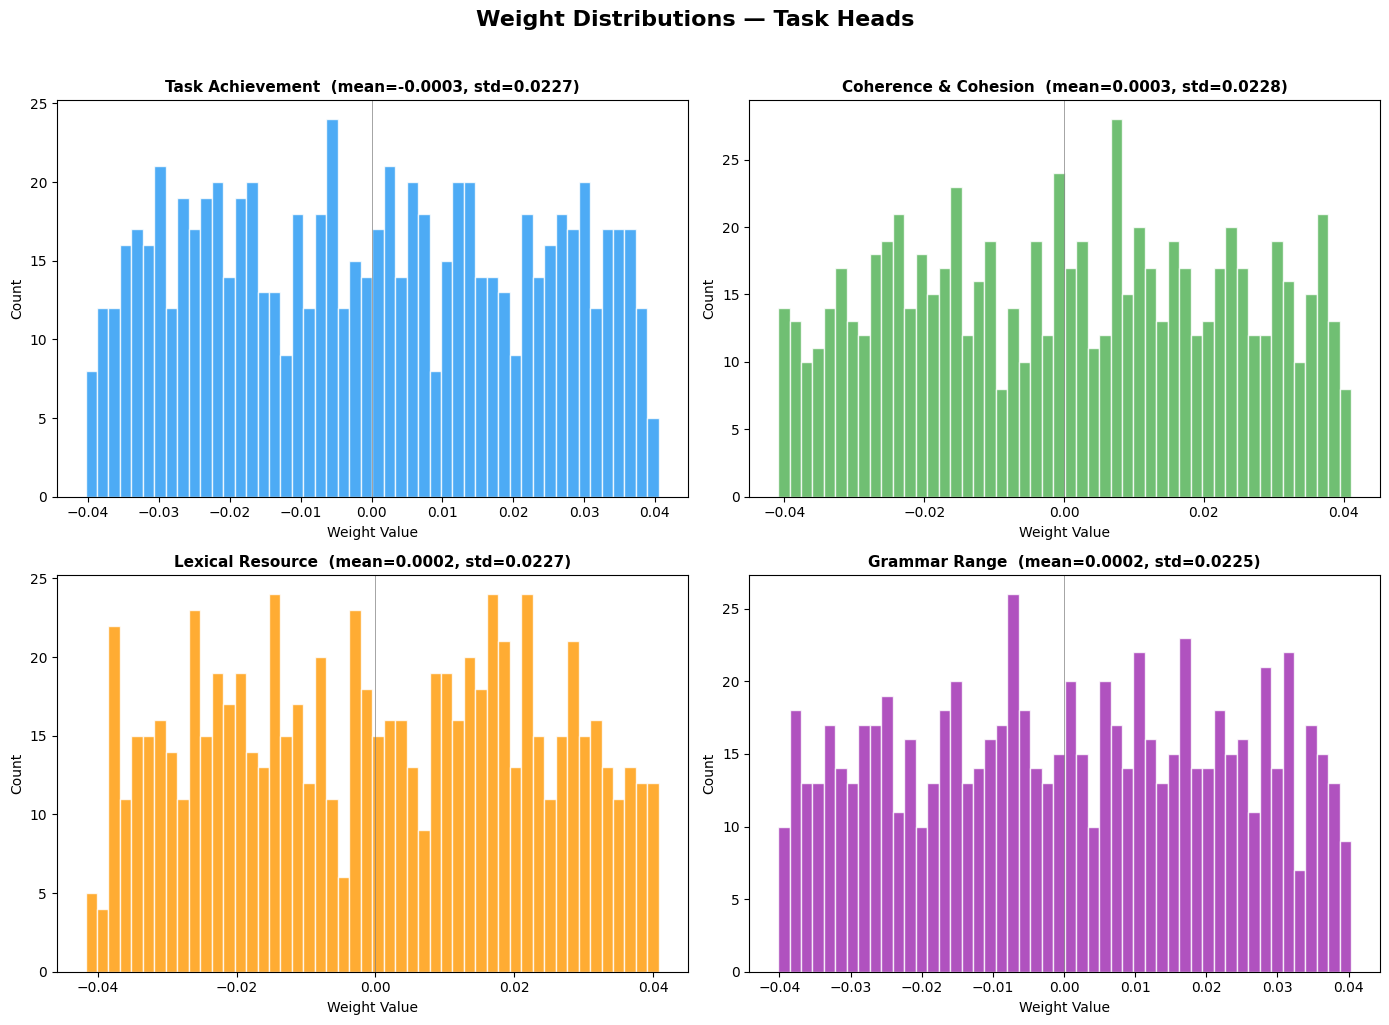

In [13]:
# Weight Distributions of Task-Specific Heads
head_names = ['ta_head', 'cc_head', 'lr_head', 'gra_head']
head_labels = ['Task Achievement', 'Coherence & Cohesion', 'Lexical Resource', 'Grammar Range']
head_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Weight Distributions — Task Heads', fontsize=16, fontweight='bold', y=1.02)

for idx, (hname, hlabel, color) in enumerate(zip(head_names, head_labels, head_colors)):
    ax = axes[idx // 2][idx % 2]
    layer = getattr(model, hname)
    weights = layer.weight.data.cpu().numpy().flatten()

    ax.hist(weights, bins=50, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_title(f'{hlabel}  (mean={weights.mean():.4f}, std={weights.std():.4f})',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Weight Value')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

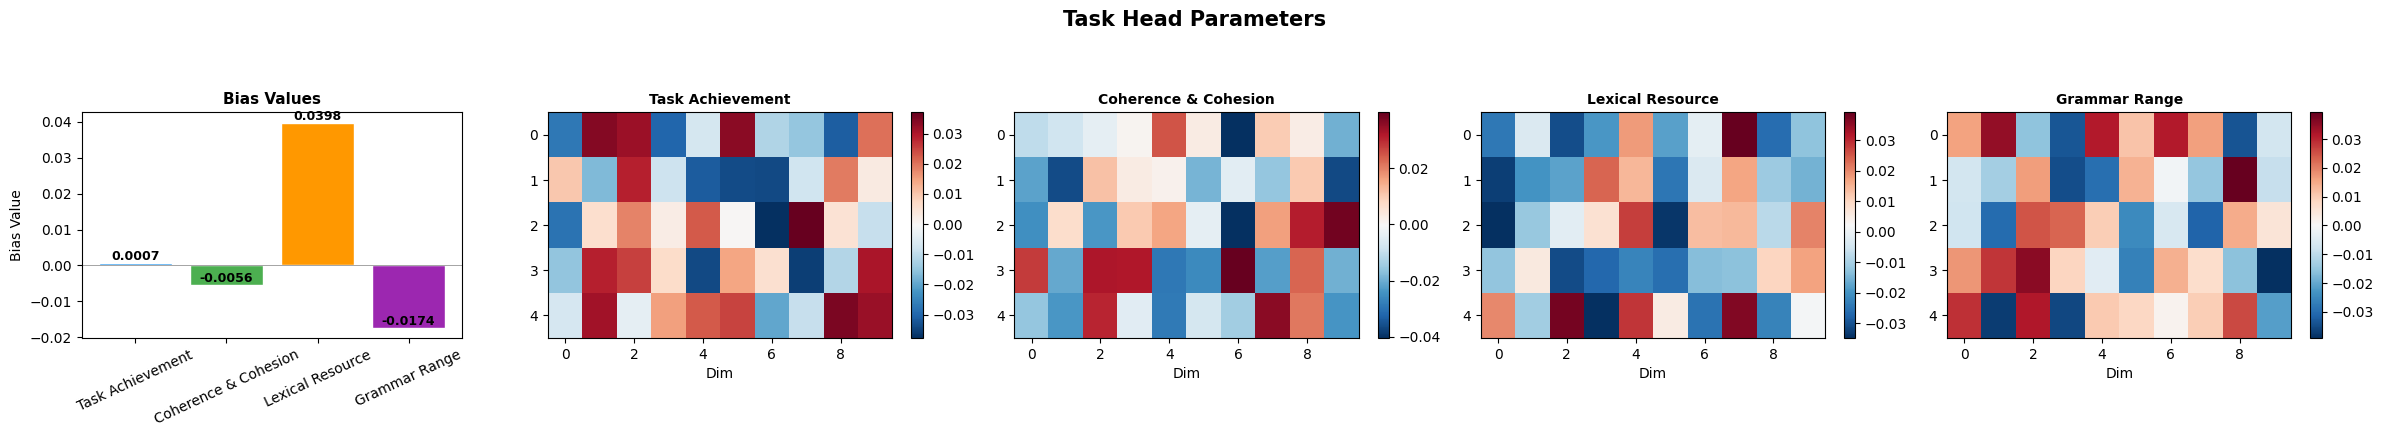

Weight L2 Norms:
           Task Achievement: 0.6315
       Coherence & Cohesion: 0.6366
           Lexical Resource: 0.6324
              Grammar Range: 0.6272


In [14]:
# Bias Values + Weight Heatmaps
fig, axes = plt.subplots(1, 5, figsize=(24, 4), gridspec_kw={'width_ratios': [1, 1, 1, 1, 1]})
fig.suptitle('Task Head Parameters', fontsize=15, fontweight='bold', y=1.08)

# Bias bar chart (first axis)
bias_vals = [getattr(model, h).bias.data.cpu().item() for h in head_names]
bars = axes[0].bar(head_labels, bias_vals, color=head_colors, edgecolor='white')
for bar, val in zip(bars, bias_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[0].set_ylabel('Bias Value')
axes[0].set_title('Bias Values', fontsize=11, fontweight='bold')
axes[0].axhline(0, color='gray', linewidth=0.5)
axes[0].tick_params(axis='x', rotation=25)

# Weight heatmaps (next 4 axes)
for idx, (hname, hlabel) in enumerate(zip(head_names, head_labels)):
    w = getattr(model, hname).weight.data.cpu().numpy()
    w_vis = w[0, :50].reshape(5, 10)
    im = axes[idx+1].imshow(w_vis, cmap='RdBu_r', aspect='auto')
    axes[idx+1].set_title(hlabel, fontsize=10, fontweight='bold')
    axes[idx+1].set_xlabel('Dim')
    plt.colorbar(im, ax=axes[idx+1], fraction=0.046)

plt.tight_layout()
plt.show()

# Print weight norms
print('Weight L2 Norms:')
for hname, hlabel in zip(head_names, head_labels):
    w = getattr(model, hname).weight.data.cpu().numpy()
    print(f'  {hlabel:>25s}: {np.linalg.norm(w):.4f}')

---
## 5. Data Augmentation Analysis

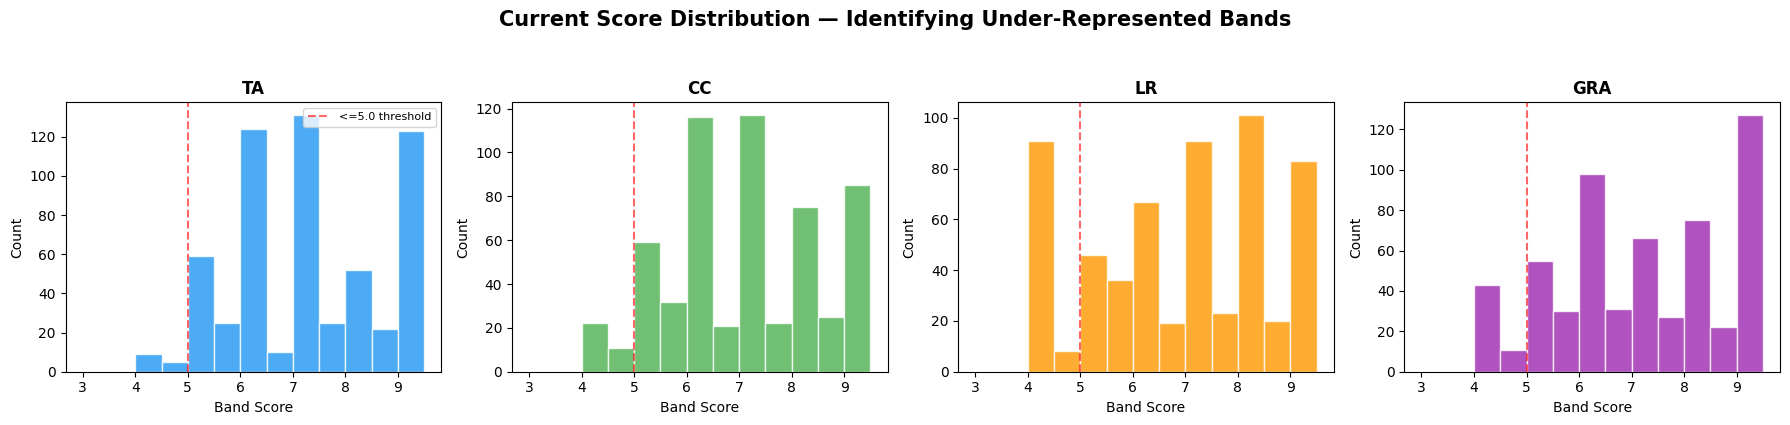

Under-represented sample counts:
      Task_Achievement:  <=5.0 = 73 (12.5%)
    Coherence_Cohesion:  <=5.0 = 92 (15.7%)
      Lexical_Resource:  <=5.0 = 145 (24.8%)
         Grammar_Range:  <=5.0 = 109 (18.6%)

Essays with ALL criteria <= 5.0: 20 / 585 (3.4%)


In [15]:
# Current Score Distribution
colors_dist = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Current Score Distribution — Identifying Under-Represented Bands',
             fontsize=15, fontweight='bold', y=1.05)

for idx, (crit, short) in enumerate(zip(CRITERIA, CRITERIA_SHORT)):
    ax = axes[idx]
    values = df[crit]
    ax.hist(values, bins=np.arange(3, 10, 0.5), color=colors_dist[idx],
            alpha=0.8, edgecolor='white')
    ax.axvline(5.0, color='red', linestyle='--', alpha=0.6, label='<=5.0 threshold')
    ax.set_title(short, fontsize=12, fontweight='bold')
    ax.set_xlabel('Band Score')
    ax.set_ylabel('Count')
    if idx == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Count rare samples
print('Under-represented sample counts:')
for crit in CRITERIA:
    low = (df[crit] <= 5.0).sum()
    total = len(df)
    print(f'  {crit:>20s}:  <=5.0 = {low} ({low/total*100:.1f}%)')

# The key metric: essays where ALL criteria are <= 5.0
all_low_mask = (df[CRITERIA] <= 5.0).all(axis=1)
print(f'\nEssays with ALL criteria <= 5.0: {all_low_mask.sum()} / {len(df)} ({all_low_mask.sum()/len(df)*100:.1f}%)')

In [16]:
# Synonym Substitution Augmentation
import random
try:
    from nltk.corpus import wordnet
    import nltk
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
    WORDNET_AVAILABLE = True
except ImportError:
    print('nltk not installed. Run: pip install nltk')
    WORDNET_AVAILABLE = False


def synonym_substitute(text, sub_rate=0.12):
    """Replace ~12% of content words with WordNet synonyms."""
    if not WORDNET_AVAILABLE:
        return text
    doc = nlp(text)
    new_tokens = []
    for token in doc:
        if (token.is_alpha and not token.is_stop
            and random.random() < sub_rate and token.pos_ in ('NOUN', 'VERB', 'ADJ', 'ADV')):
            synsets = wordnet.synsets(token.text.lower())
            synonyms = set()
            for syn in synsets:
                for lemma in syn.lemmas():
                    if lemma.name().lower() != token.text.lower() and '_' not in lemma.name():
                        synonyms.add(lemma.name())
            if synonyms:
                replacement = random.choice(list(synonyms))
                new_tokens.append(replacement)
                continue
        new_tokens.append(token.text)
    return ' '.join(new_tokens)


# Demo
sample_text = df['Essay_Text'].iloc[0][:300]
augmented = synonym_substitute(sample_text)
print('=== Original (first 300 chars) ===')
print(sample_text[:200], '...')
print('\n=== Synonym Substituted ===')
print(augmented[:200], '...')

=== Original (first 300 chars) ===
The table compares the share of revenue which people spent on four categories, namely food, electronic and equipment, music and video in the UK in 1998. Overall , music was the highest proportion amon ...

=== Synonym Substituted ===
The table compares the share of revenue which people spent on four categories , namely food , electronic and equipment , music and video in the UK in 1998 . Overall , music was the high proportion amo ...


In [18]:
# Augment Under-Represented Bands (FIXED filter)
#
# OLD (buggy): (df[CRITERIA] <= 4.5).any(axis=1) | (df[CRITERIA] >= 8.0).any(axis=1)
#   -> .any() selected mixed-score essays; >= 8.0 amplified high-band bias
#
# NEW: Target only genuinely underrepresented essays where ALL criteria are low
rare_mask = (df[CRITERIA] <= 5.0).all(axis=1)
rare_df = df[rare_mask].copy()
print(f'Rare-band essays found: {len(rare_df)} / {len(df)} ({len(rare_df)/len(df)*100:.1f}%)')

# Generate augmented versions via synonym substitution
if WORDNET_AVAILABLE and len(rare_df) > 0:
    augmented_rows = []
    for _, row in rare_df.iterrows():
        new_row = row.copy()
        new_row['Essay_Text'] = synonym_substitute(str(row['Essay_Text']), sub_rate=0.12)
        augmented_rows.append(new_row)

    aug_df = pd.DataFrame(augmented_rows)
    df_augmented = pd.concat([df, aug_df], ignore_index=True)
    print(f'Augmented dataset size: {len(df_augmented)} (added {len(aug_df)} synonym-augmented essays)')
else:
    df_augmented = df.copy()
    aug_df = pd.DataFrame()
    print('No augmentation applied (WordNet unavailable or no rare samples found)')

Rare-band essays found: 20 / 585 (3.4%)
Augmented dataset size: 605 (added 20 synonym-augmented essays)


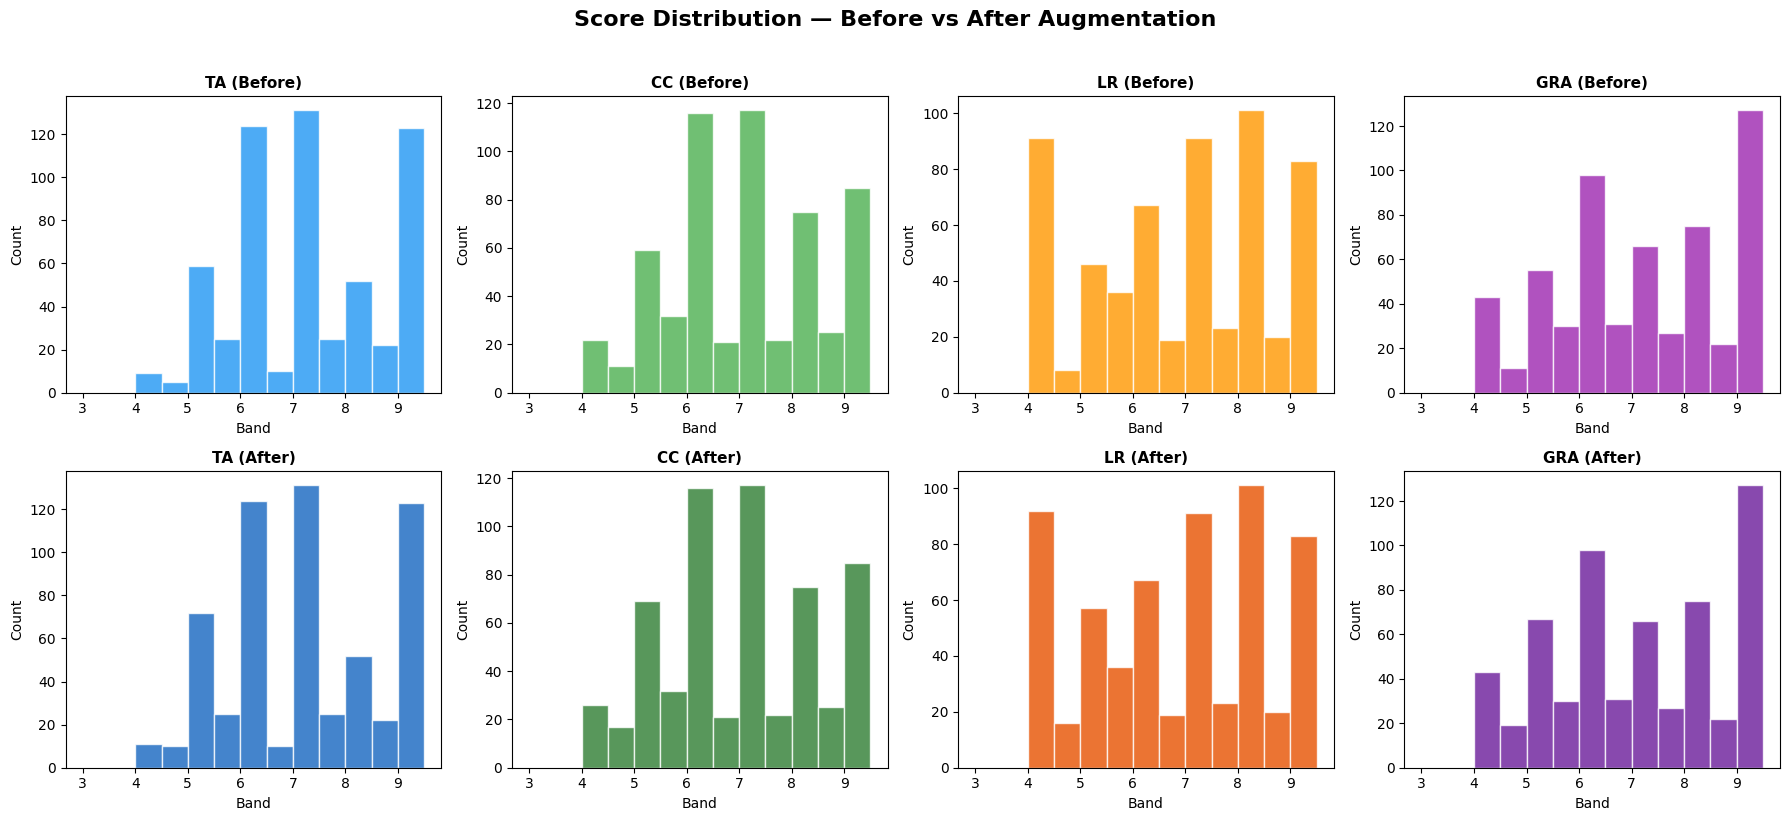

Checking cosine similarity for 20 original vs augmented essays...



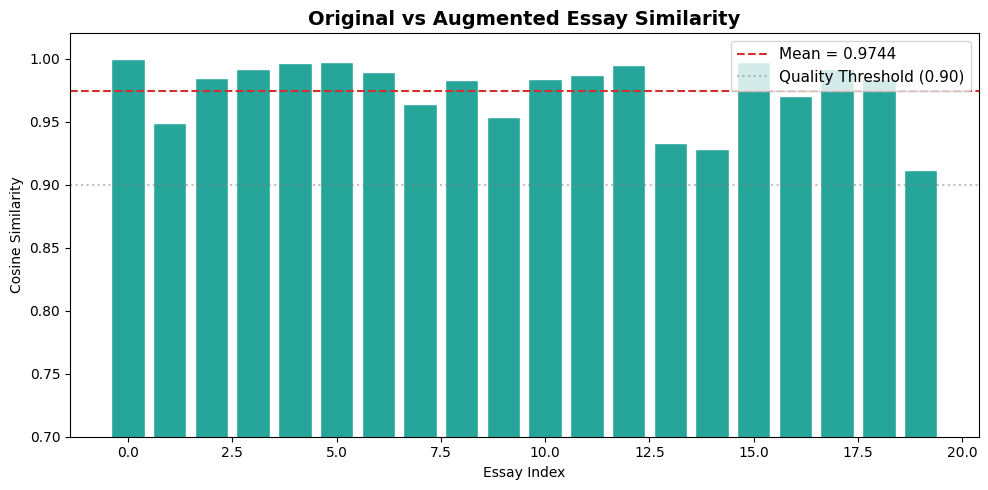


Similarity Stats:
   Mean:  0.9744
   Min:   0.9116
   Max:   0.9998
   Below 0.90: 0/20 (0%)


In [19]:
# Score Distribution: Before vs After Augmentation
colors_before = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
colors_after  = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A']
bins = np.arange(3, 10, 0.5)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Score Distribution — Before vs After Augmentation',
             fontsize=16, fontweight='bold', y=1.02)

for idx, (crit, short) in enumerate(zip(CRITERIA, CRITERIA_SHORT)):
    ax = axes[0][idx]
    ax.hist(df[crit], bins=bins, color=colors_before[idx], alpha=0.8, edgecolor='white')
    ax.set_title(f'{short} (Before)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Band')
    ax.set_ylabel('Count')

    ax = axes[1][idx]
    ax.hist(df_augmented[crit], bins=bins, color=colors_after[idx], alpha=0.8, edgecolor='white')
    ax.set_title(f'{short} (After)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Band')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

# Quality Check: Cosine Similarity
if WORDNET_AVAILABLE and len(aug_df) > 0:
    n_check = min(20, len(rare_df))
    originals  = rare_df['Essay_Text'].iloc[:n_check].tolist()
    augmenteds = aug_df['Essay_Text'].iloc[:n_check].tolist()

    print(f'Checking cosine similarity for {n_check} original vs augmented essays...\n')

    orig_embs = sim_model.encode(originals, convert_to_numpy=True)
    aug_embs  = sim_model.encode(augmenteds, convert_to_numpy=True)

    similarities = []
    for i in range(n_check):
        sim_score = util.cos_sim(orig_embs[i], aug_embs[i]).item()
        similarities.append(sim_score)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(range(n_check), similarities, color='#26A69A', edgecolor='white')
    ax.axhline(np.mean(similarities), color='#D32F2F', linestyle='--', linewidth=1.5,
               label=f'Mean = {np.mean(similarities):.4f}')
    ax.axhline(0.90, color='gray', linestyle=':', alpha=0.5, label='Quality Threshold (0.90)')
    ax.set_xlabel('Essay Index')
    ax.set_ylabel('Cosine Similarity')
    ax.set_title('Original vs Augmented Essay Similarity', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.set_ylim(0.7, 1.02)
    plt.tight_layout()
    plt.show()

    print(f'\nSimilarity Stats:')
    print(f'   Mean:  {np.mean(similarities):.4f}')
    print(f'   Min:   {np.min(similarities):.4f}')
    print(f'   Max:   {np.max(similarities):.4f}')
    below = sum(1 for s in similarities if s < 0.90)
    print(f'   Below 0.90: {below}/{n_check} ({below/n_check*100:.0f}%)')
else:
    print('Skipping quality check — no augmented data available.')

---
## Summary

| Section | What It Tells You |
|---------|-------------------|
| **Training Curves** | Whether loss converged and how the LR schedule shaped optimization |
| **Model Evaluation** | Per-criterion accuracy (MAE, RMSE, R², Within ±0.5 Band) on the held-out test set |
| **Weights & Biases** | How much each task head has learned and their parameter distributions |
| **Data Augmentation** | Whether augmenting low-band essays (all criteria ≤ 5.0) improves class balance |

### Key Changes from Previous Version
- **No in-notebook training** — models are loaded from `sayardesk_model_best.pth` and `hybrid_xgb_model.joblib`
- **Fixed augmentation filter** — changed from `any(criterion ≤ 4.5 OR ≥ 8.0)` to `all(criteria ≤ 5.0)` to avoid amplifying high-band bias
- **Training curves** — loaded from `training_history.json` generated by `advanced_model.py`

## 5. Granular Performance Audit
Analyze performance for specific score bands, particularly low (1-2) and high (8-9).

Production Hybrid Model Audit:
Band Segment         | Count | Overall MSE | Overall MAE
------------------------------------------------------------
Low Band (1-4.5)     |     4 |      0.7712 |      0.8720
Mid Band (5-7.5)     |    92 |      0.3688 |      0.4909
High Band (8-9)      |    21 |      0.9209 |      0.8028


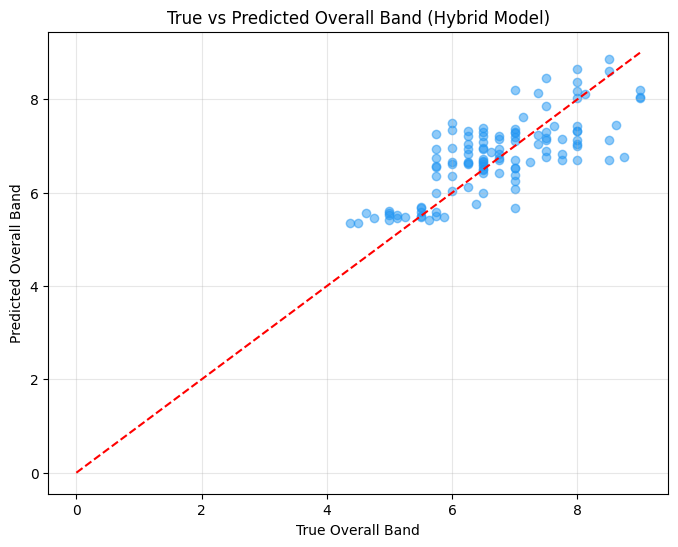

In [20]:
# Band-Specific Analysis
def analyze_bands(y_true, y_pred):
    bands = [
        ('Low Band (1-4.5)', lambda x: x < 5.0),
        ('Mid Band (5-7.5)', lambda x: (x >= 5.0) & (x < 8.0)),
        ('High Band (8-9)', lambda x: x >= 8.0)
    ]
    
    # Use Overall Band (average of criteria) for slicing
    overall_true = np.mean(y_true, axis=1)
    overall_pred = np.mean(y_pred, axis=1)
    
    print(f"{'Band Segment':20} | {'Count':5} | {'Overall MSE':11} | {'Overall MAE':11}")
    print("-" * 60)
    
    for name, condition in bands:
        mask = condition(overall_true)
        if np.any(mask):
            mse = mean_squared_error(overall_true[mask], overall_pred[mask])
            mae = mean_absolute_error(overall_true[mask], overall_pred[mask])
            print(f"{name:20} | {np.sum(mask):5} | {mse:11.4f} | {mae:11.4f}")
        else:
            print(f"{name:20} | {0:5} | N/A")

print("Production Hybrid Model Audit:")
analyze_bands(y_true, y_hybrid)

# Discrepancy Plot
plt.figure(figsize=(8, 6))
plt.scatter(np.mean(y_true, axis=1), np.mean(y_hybrid, axis=1), alpha=0.5, color='#2196F3')
plt.plot([0, 9], [0, 9], '--', color='red')
plt.xlabel('True Overall Band')
plt.ylabel('Predicted Overall Band')
plt.title('True vs Predicted Overall Band (Hybrid Model)')
plt.grid(True, alpha=0.3)
plt.show()